# Módulo 2 — Clase 4: Web scraping y procesamiento de datos no estructurados

**Curso:** Python y Políticas Públicas  
**Nivel:** Avanzado  
**Duración estimada:** 90 minutos

---

## Objetivos de la clase

Al finalizar esta clase podrás:

- Extraer tablas y datos de páginas web usando `requests` y `BeautifulSoup`
- Descargar y procesar datos abiertos del gobierno argentino directamente desde URLs
- Extraer texto y tablas de archivos PDF con `pdfplumber`
- Aplicar estas técnicas a fuentes de datos reales de política pública

---

## ¿Por qué scraping y datos no estructurados?

En el trabajo real de análisis de políticas públicas, los datos rara vez vienen en formato tabular limpio. Los analistas frecuentemente necesitan extraer información de:

- **Páginas web** con tablas HTML (presupuestos, estadísticas oficiales, Wikipedia)
- **PDFs** (proyectos de ley, informes del Ministerio de Economía, memorias de gestión)
- **Portales de datos abiertos** (datos.gob.ar, INDEC, Banco Central)

Este notebook cubre las tres fuentes más comunes.

In [1]:
# Instalación de dependencias (ejecutar solo si es necesario)
# !pip install requests beautifulsoup4 pandas matplotlib pdfplumber

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Paleta de identidad del curso ---
C = ['#2A6496', '#E07B3F', '#3D9970', '#8E5EA2', '#C0A830', '#637A8A']

mpl.rcParams.update({
    'figure.figsize'       : (10, 5),
    'font.size'            : 11,
    'axes.titlesize'       : 12,
    'axes.titleweight'     : 'normal',
    'axes.spines.top'      : False,
    'axes.spines.right'    : False,
    'legend.frameon'       : False,
    'axes.prop_cycle'      : mpl.cycler(color=C),
    'figure.dpi'           : 110,
})

def tit(ax, t, **kw):
    """Título sin negrita, alineado a la izquierda."""
    ax.set_title(t, loc='left', fontweight='normal', **kw)


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
import warnings
warnings.filterwarnings('ignore')

# Configuración general de gráficos
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Bibliotecas importadas correctamente.")

Bibliotecas importadas correctamente.


---

# Parte 1: Web scraping con BeautifulSoup

## El flujo básico del scraping

```
URL  →  requests.get()  →  HTML  →  BeautifulSoup  →  datos estructurados
```

**Por qué Wikipedia es una buena fuente para practicar:**
- Sus tablas HTML tienen estructura consistente (`class="wikitable"`)
- Es un sitio estable, raramente cambia su estructura
- Tiene datos sobre Argentina bien mantenidos
- No tiene anti-scraping agresivo

**Fuente:** Usaremos la tabla de producto bruto geográfico por provincia argentina de Wikipedia.

## 1.1 Conceptos clave de BeautifulSoup

BeautifulSoup convierte el HTML (texto plano) en un árbol de objetos Python que podemos navegar:

```python
soup.find("tag")           # Primer elemento que coincide
soup.find_all("tag")       # Todos los elementos que coinciden
soup.find("tag", {"class": "nombre"})  # Filtrar por clase CSS
elemento.text              # Texto visible (sin etiquetas HTML)
elemento.get("href")       # Atributo de la etiqueta
```

Las tablas en HTML tienen esta estructura:
```html
<table>
  <thead><tr><th>Columna 1</th><th>Columna 2</th></tr></thead>
  <tbody>
    <tr><td>valor 1</td><td>valor 2</td></tr>
    ...
  </tbody>
</table>
```

In [4]:
# URL de la tabla de PBG provincial en Wikipedia
URL_WIKI = "https://es.wikipedia.org/wiki/Anexo:Provincias_de_Argentina_por_producto_bruto_geogr%C3%A1fico"

# Headers para simular un navegador web real
# Sin esto, algunos servidores bloquean las solicitudes automatizadas
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

print(f"Conectando a: {URL_WIKI[:60]}...")

try:
    response = requests.get(URL_WIKI, headers=HEADERS, timeout=30)
    response.raise_for_status()
    print(f"Respuesta HTTP: {response.status_code} OK")
    print(f"Tamaño del HTML descargado: {len(response.text):,} caracteres")
except requests.exceptions.ConnectionError:
    print("Error: No se pudo conectar con Wikipedia. Verificar conexión a internet.")
    response = None
except requests.exceptions.HTTPError as e:
    print(f"Error HTTP: {e}")
    response = None
except requests.exceptions.Timeout:
    print("Error: Tiempo de espera agotado.")
    response = None

Conectando a: https://es.wikipedia.org/wiki/Anexo:Provincias_de_Argentina_...


Error HTTP: 404 Client Error: Not Found for url: https://es.wikipedia.org/wiki/Anexo:Provincias_de_Argentina_por_producto_bruto_geogr%C3%A1fico


In [5]:
# Parsear el HTML con BeautifulSoup
if response is not None:
    soup = BeautifulSoup(response.text, "html.parser")
    
    # Buscar todas las wikitables en la página
    tablas = soup.find_all("table", {"class": "wikitable"})
    print(f"Tablas encontradas en la página: {len(tablas)}")
    
    # Ver los encabezados de cada tabla para identificar la correcta
    for i, tabla in enumerate(tablas):
        headers = [th.get_text(strip=True) for th in tabla.find_all("th")[:5]]
        print(f"  Tabla {i}: {headers}")
else:
    print("No hay respuesta disponible.")
    tablas = []

No hay respuesta disponible.


In [6]:
def limpiar_numero(texto: str) -> float | None:
    """
    Limpia un string con formato de número (con $, puntos, comas, espacios)
    y lo convierte a float. Retorna None si no se puede convertir.
    
    Ejemplos:
        '$1.234.567' → 1234567.0
        '12,5%'      → 12.5
        'n.d.'       → None
    """
    if not texto or texto.strip() in ["", "—", "-", "n.d.", "N/D", "s/d"]:
        return None
    # Remover símbolos no numéricos excepto punto y coma
    limpio = re.sub(r"[^\d,\.]", "", texto.strip())
    if not limpio:
        return None
    try:
        # Detectar si el punto es separador de miles o decimal
        if "," in limpio and "." in limpio:
            # Formato: 1.234.567,89 → quitar puntos, cambiar coma por punto
            limpio = limpio.replace(".", "").replace(",", ".")
        elif "," in limpio:
            # Coma como decimal: 12,5 → 12.5
            limpio = limpio.replace(",", ".")
        elif limpio.count(".") > 1:
            # Múltiples puntos = separadores de miles: 1.234.567
            limpio = limpio.replace(".", "")
        return float(limpio)
    except ValueError:
        return None


# Prueba de la función
test_cases = ["$1.234.567", "12,5", "1.234.567,89", "100.000", "n.d.", ""]
for tc in test_cases:
    print(f"  '{tc}' → {limpiar_numero(tc)}")

  '$1.234.567' → 1234567.0
  '12,5' → 12.5
  '1.234.567,89' → 1234567.89
  '100.000' → 100.0
  'n.d.' → None
  '' → None


In [7]:
def extraer_tabla_wikipedia(tablas: list, indice: int = 0) -> pd.DataFrame:
    """
    Extrae una wikitable de Wikipedia y la convierte en DataFrame.
    
    Parámetros
    ----------
    tablas : list
        Lista de elementos <table> encontrados por BeautifulSoup
    indice : int
        Índice de la tabla a extraer (0 = primera)
    
    Retorna
    -------
    pd.DataFrame con los datos de la tabla
    """
    if not tablas or indice >= len(tablas):
        print(f"Error: no existe la tabla índice {indice}.")
        return pd.DataFrame()
    
    tabla = tablas[indice]
    
    # Extraer encabezados
    headers = []
    header_row = tabla.find("tr")
    if header_row:
        for celda in header_row.find_all(["th", "td"]):
            texto = celda.get_text(separator=" ", strip=True)
            # Limpiar caracteres especiales de Wikipedia
            texto = re.sub(r"\[\d+\]", "", texto)  # Quitar referencias [1], [2]
            headers.append(texto)
    
    # Extraer filas de datos
    rows = []
    for fila in tabla.find_all("tr")[1:]:  # Saltar la primera fila (encabezado)
        celdas = fila.find_all(["td", "th"])
        if len(celdas) == 0:
            continue
        fila_datos = []
        for celda in celdas:
            texto = celda.get_text(separator=" ", strip=True)
            texto = re.sub(r"\[\d+\]", "", texto)  # Quitar referencias
            fila_datos.append(texto)
        rows.append(fila_datos)
    
    if not rows:
        print("Error: no se encontraron filas de datos.")
        return pd.DataFrame()
    
    # Crear DataFrame, manejar diferencias en número de columnas
    df = pd.DataFrame(rows)
    if headers and len(headers) == df.shape[1]:
        df.columns = headers
    
    return df


# Extraer la tabla principal de PBG
if tablas:
    df_pbg_raw = extraer_tabla_wikipedia(tablas, indice=0)
    print(f"Dimensiones del DataFrame crudo: {df_pbg_raw.shape}")
    print("\nPrimeras 5 filas:")
    display(df_pbg_raw.head())
    print("\nNombres de columnas detectados:")
    print(df_pbg_raw.columns.tolist())
else:
    print("No hay tablas disponibles. Usando datos de ejemplo.")
    # Datos de respaldo para que el notebook funcione sin conexión
    df_pbg_raw = pd.DataFrame({
        "Provincia": ["Buenos Aires", "Ciudad de Buenos Aires", "Córdoba",
                      "Santa Fe", "Mendoza", "Tucumán", "Entre Ríos",
                      "Chubut", "Neuquén", "Río Negro"],
        "PBG (mill. $)": ["14.234.567", "8.123.456", "4.567.890",
                          "3.987.654", "2.345.678", "1.234.567",
                          "987.654", "1.345.678", "1.567.890", "876.543"],
        "% del PBI": ["38,5", "22,0", "12,4", "10,8", "6,3",
                      "3,3", "2,7", "3,6", "4,2", "2,4"]
    })

No hay tablas disponibles. Usando datos de ejemplo.


In [8]:
# Limpieza del DataFrame
# Identificar columnas numéricas y convertirlas
df_pbg = df_pbg_raw.copy()

# Renombrar columnas de forma más robusta
columnas_originales = df_pbg.columns.tolist()
print("Columnas originales:")
for i, col in enumerate(columnas_originales):
    print(f"  [{i}] '{col}'")

# Detectar y convertir columnas que parecen numéricas
for col in df_pbg.columns:
    # Intentar convertir muestras de la columna
    muestra = df_pbg[col].dropna().head(3).tolist()
    valores_convertidos = [limpiar_numero(str(v)) for v in muestra]
    
    # Si más del 60% de la muestra es convertible, es columna numérica
    convertibles = sum(1 for v in valores_convertidos if v is not None)
    if len(muestra) > 0 and convertibles / len(muestra) > 0.6:
        df_pbg[col] = df_pbg[col].apply(lambda x: limpiar_numero(str(x)) if pd.notna(x) else None)
        print(f"Columna '{col}' convertida a numérica.")

print(f"\nDataFrame limpio: {df_pbg.shape[0]} filas, {df_pbg.shape[1]} columnas")
display(df_pbg.head(8))

Columnas originales:
  [0] 'Provincia'
  [1] 'PBG (mill. $)'
  [2] '% del PBI'
Columna 'PBG (mill. $)' convertida a numérica.
Columna '% del PBI' convertida a numérica.

DataFrame limpio: 10 filas, 3 columnas


,Provincia,PBG (mill. $),% del PBI
0,Buenos Aires,1.423457e+07,38.5
1,Ciudad de Buenos Aires,8.123456e+06,22.0
2,Córdoba,4.567890e+06,12.4
3,Santa Fe,3.987654e+06,10.8
4,Mendoza,2.345678e+06,6.3
5,Tucumán,1.234567e+06,3.3
6,Entre Ríos,9.876540e+02,2.7
7,Chubut,1.345678e+06,3.6


Columnas numéricas encontradas: ['PBG (mill. $)', '% del PBI']


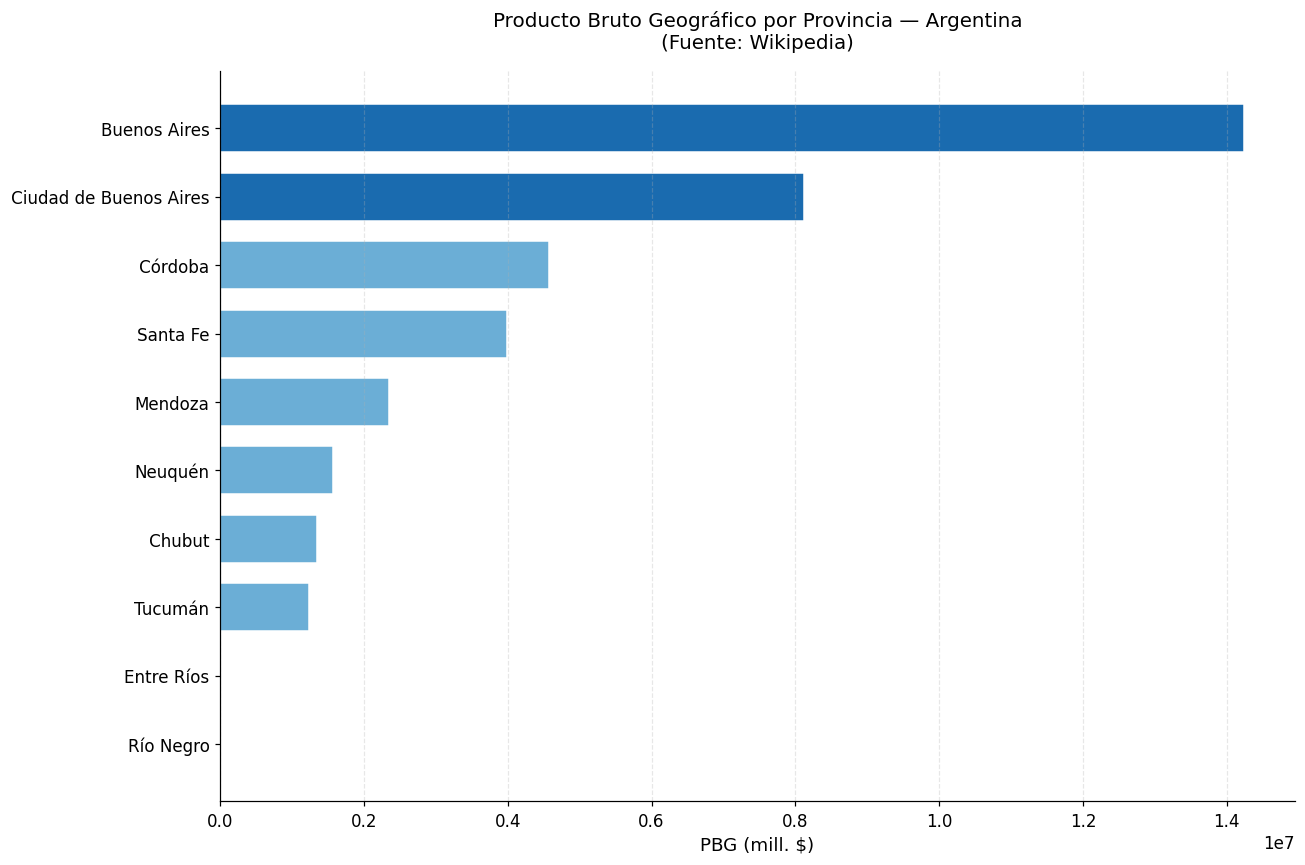

In [9]:
# Visualización: identificar columnas de provincia y PBG
# (adaptamos según lo que encontró el scraper)
col_provincia = df_pbg.columns[0]  # Primera columna = provincias

# Buscar la columna numérica principal (PBG o % del PIB)
cols_numericas = df_pbg.select_dtypes(include=[float, int]).columns.tolist()
print(f"Columnas numéricas encontradas: {cols_numericas}")

if cols_numericas:
    col_valor = cols_numericas[0]  # Primera columna numérica
    
    # Filtrar filas con datos válidos y ordenar
    df_plot = (
        df_pbg[[col_provincia, col_valor]]
        .dropna()
        .sort_values(col_valor, ascending=True)
        .tail(15)  # Top 15 provincias
    )
    
    # Gráfico de barras horizontales
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colores = ["#1a6baf" if str(prov).lower().strip() in ["buenos aires", "ciudad de buenos aires"]
               else "#6baed6"
               for prov in df_plot[col_provincia]]
    
    ax.barh(df_plot[col_provincia], df_plot[col_valor],
            color=colores, edgecolor="white", height=0.7)
    
    ax.set_xlabel(f"{col_valor}", fontsize=12)
    ax.set_title("Producto Bruto Geográfico por Provincia — Argentina\n"
                 "(Fuente: Wikipedia)",
                 fontsize=13, pad=15)
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron columnas numéricas válidas en la tabla scrapada.")
    print("Esto puede ocurrir si la estructura de la tabla Wikipedia cambió.")
    display(df_pbg.head())


---

# Parte 2: Datos del Portal datos.gob.ar

## El portal de datos abiertos del gobierno argentino

[datos.gob.ar](https://datos.gob.ar) es el portal oficial del Estado Nacional argentino para datos abiertos. Muchos datasets están disponibles como CSVs descargables directamente por URL, lo que facilita la integración con Python.

**Ventajas sobre el scraping:**
- Datos estructurados (CSV/Excel) sin necesidad de parsear HTML
- URLs estables y documentadas
- Datos oficiales del gobierno

**Vamos a usar:** el índice de precios al consumidor (IPC) por categorías, base diciembre 2016.

In [10]:
# URL directa al CSV de IPC por categorías
URL_IPC = (
    "https://infra.datos.gob.ar/catalog/sspm/dataset/145/distribution/145.9/"
    "download/indice-precios-al-consumidor-apertura-por-categorias-base-diciembre-2016-mensual.csv"
)

print("Descargando IPC desde datos.gob.ar...")

try:
    df_ipc = pd.read_csv(URL_IPC, encoding="utf-8")
    print(f"Datos descargados exitosamente: {df_ipc.shape[0]:,} filas x {df_ipc.shape[1]} columnas")
    print(f"\nPrimeras filas:")
    display(df_ipc.head())
    print(f"\nColumnas disponibles:")
    print(df_ipc.columns.tolist())
    print(f"\nPeríodo: {df_ipc.iloc[0, 0]} → {df_ipc.iloc[-1, 0]}")
except Exception as e:
    print(f"Error al descargar el CSV: {e}")
    print("\nUsando datos de ejemplo para continuar con la clase...")
    # Datos sintéticos de respaldo para uso offline
    import datetime
    fechas = pd.date_range(start="2017-01-01", end="2023-12-01", freq="MS")
    np_rand = __import__('numpy').random
    np_rand.seed(42)
    base = 100
    indices = [base]
    for _ in range(len(fechas) - 1):
        base *= (1 + np_rand.uniform(0.02, 0.08))
        indices.append(round(base, 2))
    df_ipc = pd.DataFrame({
        "indice_tiempo": fechas.strftime("%Y-%m-%d"),
        "nivel_general": indices,
        "alimentos_y_bebidas_no_alcoholicas": [v * np_rand.uniform(0.95, 1.05) for v in indices],
        "indumentaria": [v * np_rand.uniform(0.90, 1.10) for v in indices],
        "vivienda_agua_electricidad_gas": [v * np_rand.uniform(0.92, 1.08) for v in indices],
        "transporte": [v * np_rand.uniform(0.88, 1.12) for v in indices]
    })
    display(df_ipc.head())

Descargando IPC desde datos.gob.ar...


Error al descargar el CSV: HTTP Error 403: Forbidden

Usando datos de ejemplo para continuar con la clase...


,indice_tiempo,nivel_general,alimentos_y_bebidas_no_alcoholicas,indumentaria,vivienda_agua_electricidad_gas,transporte
0,2017-01-01,100.00,95.635584,93.730370,98.161564,88.977491
1,2017-02-01,104.25,102.279491,94.675162,110.106960,113.143624
2,2017-03-01,112.28,110.317158,114.321092,108.991040,117.768009
3,2017-04-01,119.46,122.202875,123.702368,113.142817,118.719553
4,2017-05-01,126.14,127.875150,113.944478,127.286386,113.964992


In [11]:
# Exploración del DataFrame del IPC
print("=== Estructura del dataset IPC ===")
print(f"Forma: {df_ipc.shape}")
print(f"\nTipos de datos:")
print(df_ipc.dtypes)
print(f"\nEstadísticas descriptivas (primeras 5 columnas numéricas):")
cols_num = df_ipc.select_dtypes(include='number').columns[:5]
display(df_ipc[cols_num].describe().round(2))

=== Estructura del dataset IPC ===
Forma: (84, 6)

Tipos de datos:
indice_tiempo                          object
nivel_general                         float64
alimentos_y_bebidas_no_alcoholicas    float64
indumentaria                          float64
vivienda_agua_electricidad_gas        float64
transporte                            float64
dtype: object

Estadísticas descriptivas (primeras 5 columnas numéricas):


,nivel_general,alimentos_y_bebidas_no_alcoholicas,indumentaria,vivienda_agua_electricidad_gas,transporte
count,84.00,84.00,84.00,84.00,84.00
mean,1240.37,1238.88,1255.96,1229.22,1253.96
std,1292.07,1292.44,1330.72,1265.24,1311.74
min,100.00,95.64,93.73,98.16,88.98
25%,262.78,263.34,259.41,277.63,254.52
50%,666.88,655.54,645.42,662.13,655.23
75%,1821.44,1764.50,1896.10,1946.56,1872.20
max,4936.64,4906.62,5082.62,4578.04,5141.04


In [12]:
# Preprocesamiento: convertir la columna de fecha y seleccionar categorías clave
df_ipc_proc = df_ipc.copy()

# Identificar la columna de fecha (generalmente la primera)
col_fecha = df_ipc_proc.columns[0]
df_ipc_proc[col_fecha] = pd.to_datetime(df_ipc_proc[col_fecha], errors="coerce")
df_ipc_proc = df_ipc_proc.dropna(subset=[col_fecha])
df_ipc_proc = df_ipc_proc.sort_values(col_fecha)

print(f"Rango temporal: {df_ipc_proc[col_fecha].min().strftime('%b %Y')} → "
      f"{df_ipc_proc[col_fecha].max().strftime('%b %Y')}")

# Seleccionar columnas de interés (nivel general + algunas categorías)
# Buscar columnas que contengan palabras clave
cols_disponibles = df_ipc_proc.select_dtypes(include='number').columns.tolist()
print(f"\nColumnas numéricas disponibles ({len(cols_disponibles)}):")
for col in cols_disponibles[:10]:  # Mostrar solo las primeras 10
    print(f"  - {col}")

# Seleccionar hasta 5 columnas para graficar
cols_grafico = cols_disponibles[:5]
print(f"\nColumnas seleccionadas para visualización: {cols_grafico}")

Rango temporal: Jan 2017 → Dec 2023

Columnas numéricas disponibles (5):
  - nivel_general
  - alimentos_y_bebidas_no_alcoholicas
  - indumentaria
  - vivienda_agua_electricidad_gas
  - transporte

Columnas seleccionadas para visualización: ['nivel_general', 'alimentos_y_bebidas_no_alcoholicas', 'indumentaria', 'vivienda_agua_electricidad_gas', 'transporte']


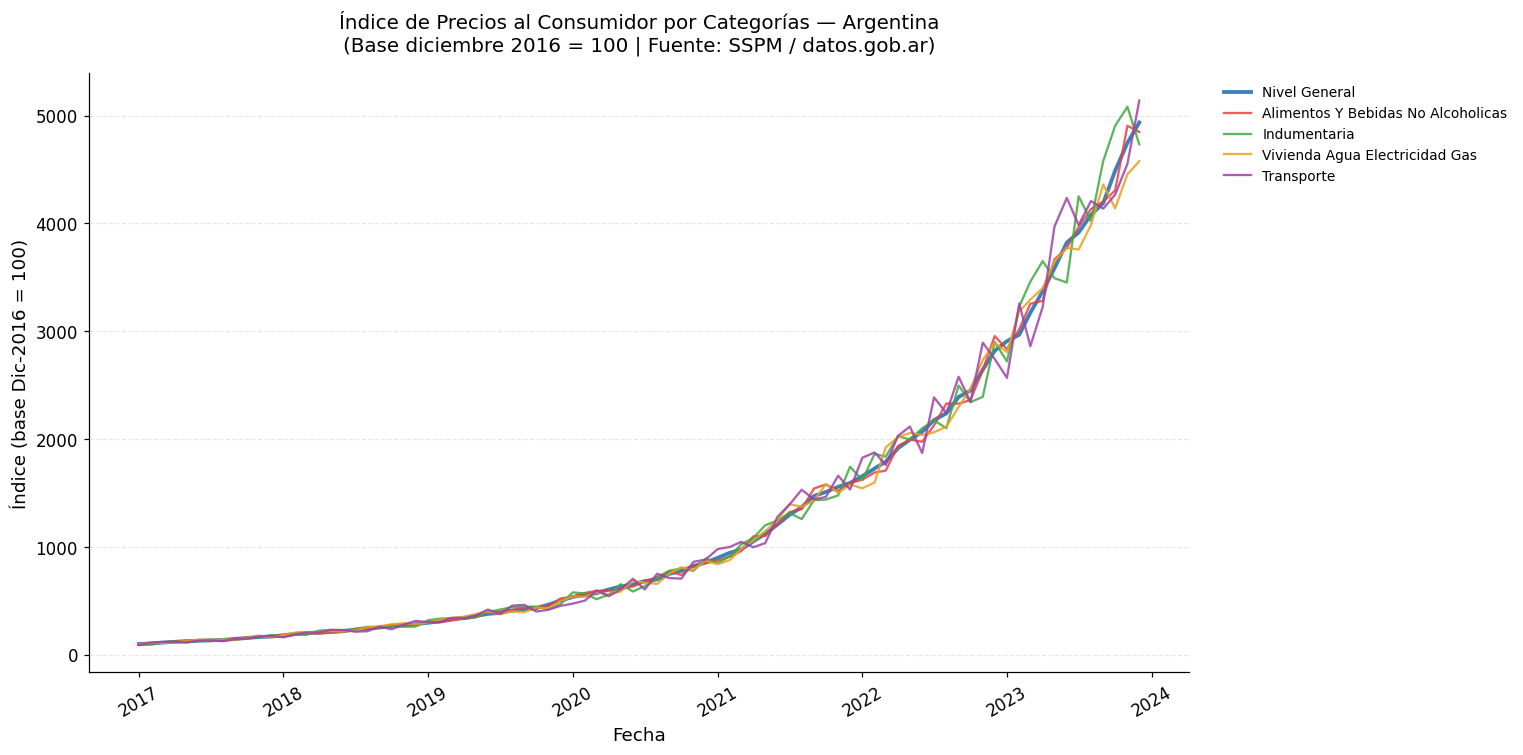


=== Variación acumulada desde inicio del período ===
  nivel_general: +4,837%
  alimentos_y_bebidas_no_alcoholicas: +4,969%
  indumentaria: +4,950%
  vivienda_agua_electricidad_gas: +4,564%
  transporte: +5,678%


In [13]:
# Visualización: evolución del IPC por categorías
import matplotlib.cm as cm

colores_lineas = ["#1a6baf", "#e84040", "#40a840", "#e8a020", "#a040a8"]

fig, ax = plt.subplots(figsize=(14, 7))

for i, col in enumerate(cols_grafico):
    if col in df_ipc_proc.columns:
        serie = df_ipc_proc[[col_fecha, col]].dropna()
        label = col.replace("_", " ").replace("-", " ").title()[:40]
        lw = 2.5 if i == 0 else 1.5
        ax.plot(serie[col_fecha], serie[col],
                label=label, color=colores_lineas[i],
                linewidth=lw, alpha=0.85)

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Índice (base Dic-2016 = 100)", fontsize=12)
ax.set_title("Índice de Precios al Consumidor por Categorías — Argentina\n"
             "(Base diciembre 2016 = 100 | Fuente: SSPM / datos.gob.ar)",
             fontsize=13, pad=15)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Calcular variación acumulada
print("\n=== Variación acumulada desde inicio del período ===")
for col in cols_grafico:
    if col in df_ipc_proc.columns:
        serie_val = df_ipc_proc[col].dropna()
        if len(serie_val) > 1:
            var_acum = (serie_val.iloc[-1] / serie_val.iloc[0] - 1) * 100
            print(f"  {col[:50]}: {var_acum:+,.0f}%")


---

# Parte 3: Extracción de datos desde PDF con pdfplumber

## ¿Por qué PDFs en política pública?

Una enorme cantidad de información oficial en Argentina llega en formato PDF:
- Proyectos de Ley de Presupuesto (MEFP)
- Informes de gestión de organismos públicos
- Memorias anuales del BCRA, INDEC, etc.
- Resoluciones ministeriales y decretos

Para automatizar el procesamiento de esta información, `pdfplumber` es la biblioteca más conveniente en Python.

## La biblioteca `pdfplumber`

`pdfplumber` se especializa en extraer texto **con información de posición** y **tablas** de PDFs. Es más poderosa que `PyPDF2` para PDFs con tablas numéricas.

```
pip install pdfplumber
```

In [14]:
# Verificar si pdfplumber está instalado
try:
    import pdfplumber
    print(f"pdfplumber instalado — versión: {pdfplumber.__version__}")
    PDFPLUMBER_DISPONIBLE = True
except ImportError:
    print("pdfplumber no está instalado.")
    print("Para instalarlo: pip install pdfplumber")
    PDFPLUMBER_DISPONIBLE = False

pdfplumber instalado — versión: 0.11.9


## 3.1 Estructura básica de uso

La API de `pdfplumber` sigue un patrón de context manager:

In [15]:
# Patrón básico de uso de pdfplumber
# (este bloque es demostrativo — necesita un archivo .pdf real)

CODIGO_BASICO = '''
import pdfplumber

# Abrir el PDF
with pdfplumber.open("presupuesto.pdf") as pdf:

    # Información general del documento
    print(f"Páginas: {len(pdf.pages)}")
    print(f"Metadatos: {pdf.metadata}")

    # Extraer texto de la primera página
    page = pdf.pages[0]
    text = page.extract_text()
    print(text[:500])  # Primeros 500 caracteres

    # Extraer tablas de la primera página
    tables = page.extract_tables()
    print(f"Tablas encontradas: {len(tables)}")

    if tables:
        # La primera tabla como DataFrame
        df = pd.DataFrame(tables[0][1:], columns=tables[0][0])
        print(df.head())
'''

print("Código básico de pdfplumber:")
print("=" * 60)
print(CODIGO_BASICO)

Código básico de pdfplumber:

import pdfplumber

# Abrir el PDF
with pdfplumber.open("presupuesto.pdf") as pdf:

    # Información general del documento
    print(f"Páginas: {len(pdf.pages)}")
    print(f"Metadatos: {pdf.metadata}")

    # Extraer texto de la primera página
    page = pdf.pages[0]
    text = page.extract_text()
    print(text[:500])  # Primeros 500 caracteres

    # Extraer tablas de la primera página
    tables = page.extract_tables()
    print(f"Tablas encontradas: {len(tables)}")

    if tables:
        # La primera tabla como DataFrame
        df = pd.DataFrame(tables[0][1:], columns=tables[0][0])
        print(df.head())



## 3.2 Caso de uso real: presupuesto del MEFP

El Ministerio de Economía publica anualmente el proyecto de Ley de Presupuesto en PDF. Usualmente contiene tablas con créditos por jurisdicción, objeto del gasto y fuente de financiamiento.

El flujo de trabajo típico es:

```
PDF del MEFP → pdfplumber → lista de tablas → DataFrame → análisis
```

In [16]:
# Función para extraer todas las tablas de un PDF a DataFrames
def extraer_tablas_pdf(ruta_pdf: str, paginas: list = None) -> list:
    """
    Extrae todas las tablas de un PDF y las devuelve como lista de DataFrames.
    
    Parámetros
    ----------
    ruta_pdf : str
        Ruta al archivo PDF
    paginas : list, opcional
        Lista de índices de páginas a procesar (0-indexado).
        Si es None, procesa todas las páginas.
    
    Retorna
    -------
    list of pd.DataFrame
    """
    if not PDFPLUMBER_DISPONIBLE:
        print("Error: pdfplumber no está instalado.")
        return []
    
    try:
        import pdfplumber
    except ImportError:
        return []
    
    resultados = []
    
    try:
        with pdfplumber.open(ruta_pdf) as pdf:
            total_paginas = len(pdf.pages)
            indices = paginas if paginas is not None else range(total_paginas)
            
            print(f"PDF: {ruta_pdf}")
            print(f"Total de páginas: {total_paginas}")
            
            for i in indices:
                if i >= total_paginas:
                    continue
                page = pdf.pages[i]
                tables = page.extract_tables()
                
                for j, table in enumerate(tables):
                    if not table or not table[0]:
                        continue
                    # Primera fila como encabezado
                    headers = [str(h) if h else f"col_{k}"
                               for k, h in enumerate(table[0])]
                    df = pd.DataFrame(table[1:], columns=headers)
                    df["_pagina"] = i + 1
                    df["_tabla"] = j + 1
                    resultados.append(df)
                    print(f"  Página {i+1}, Tabla {j+1}: {df.shape[0]} filas × {df.shape[1]-2} columnas")
    
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{ruta_pdf}'.")
    except Exception as e:
        print(f"Error al procesar el PDF: {e}")
    
    return resultados


# Función para extraer texto de un PDF
def extraer_texto_pdf(ruta_pdf: str, paginas: list = None) -> str:
    """
    Extrae todo el texto de un PDF (útil para búsqueda de palabras clave).
    """
    if not PDFPLUMBER_DISPONIBLE:
        return ""
    
    try:
        import pdfplumber
    except ImportError:
        return ""
    
    texto_total = []
    try:
        with pdfplumber.open(ruta_pdf) as pdf:
            indices = paginas if paginas is not None else range(len(pdf.pages))
            for i in indices:
                if i >= len(pdf.pages):
                    continue
                texto = pdf.pages[i].extract_text()
                if texto:
                    texto_total.append(f"--- Página {i+1} ---\n{texto}")
    except Exception as e:
        print(f"Error: {e}")
    
    return "\n\n".join(texto_total)


print("Funciones de extracción PDF definidas.")
print("\nEjemplo de uso:")
print("  tablas = extraer_tablas_pdf('presupuesto_2024.pdf', paginas=[0, 1, 2])")
print("  texto  = extraer_texto_pdf('informe_mefp.pdf', paginas=[0])")

Funciones de extracción PDF definidas.

Ejemplo de uso:
  tablas = extraer_tablas_pdf('presupuesto_2024.pdf', paginas=[0, 1, 2])
  texto  = extraer_texto_pdf('informe_mefp.pdf', paginas=[0])


## 3.3 Flujo de trabajo: de PDF a análisis

Cuando recibís un PDF con datos presupuestarios, el flujo completo es:

=== Simulación: datos extraídos de un PDF de presupuesto ===

Tabla de presupuesto procesada:


,Jurisdicción,Crédito_Vigente_MM,Devengado_MM,Pagado_MM,Ejecucion_pct
2,Ministerio de Economía,2345670,2290450,2280340,97.6
4,Ministerio de Educación,980234,971230,965670,99.1
8,Ministerio de Obras Públicas,789012,756780,745670,95.9
9,Ministerio de Desarrollo Social,678901,665430,659870,98.0
3,Ministerio de Salud,567890,556780,548920,98.0
6,Ministerio de Seguridad,456780,448920,445670,98.3
5,Ministerio de Defensa,234560,229870,226780,98.0
1,Jefatura de Gabinete,128450,125340,124560,97.6
7,Ministerio de Justicia,123450,120340,119230,97.5
0,Presidencia de la Nación,45230,44120,43890,97.5


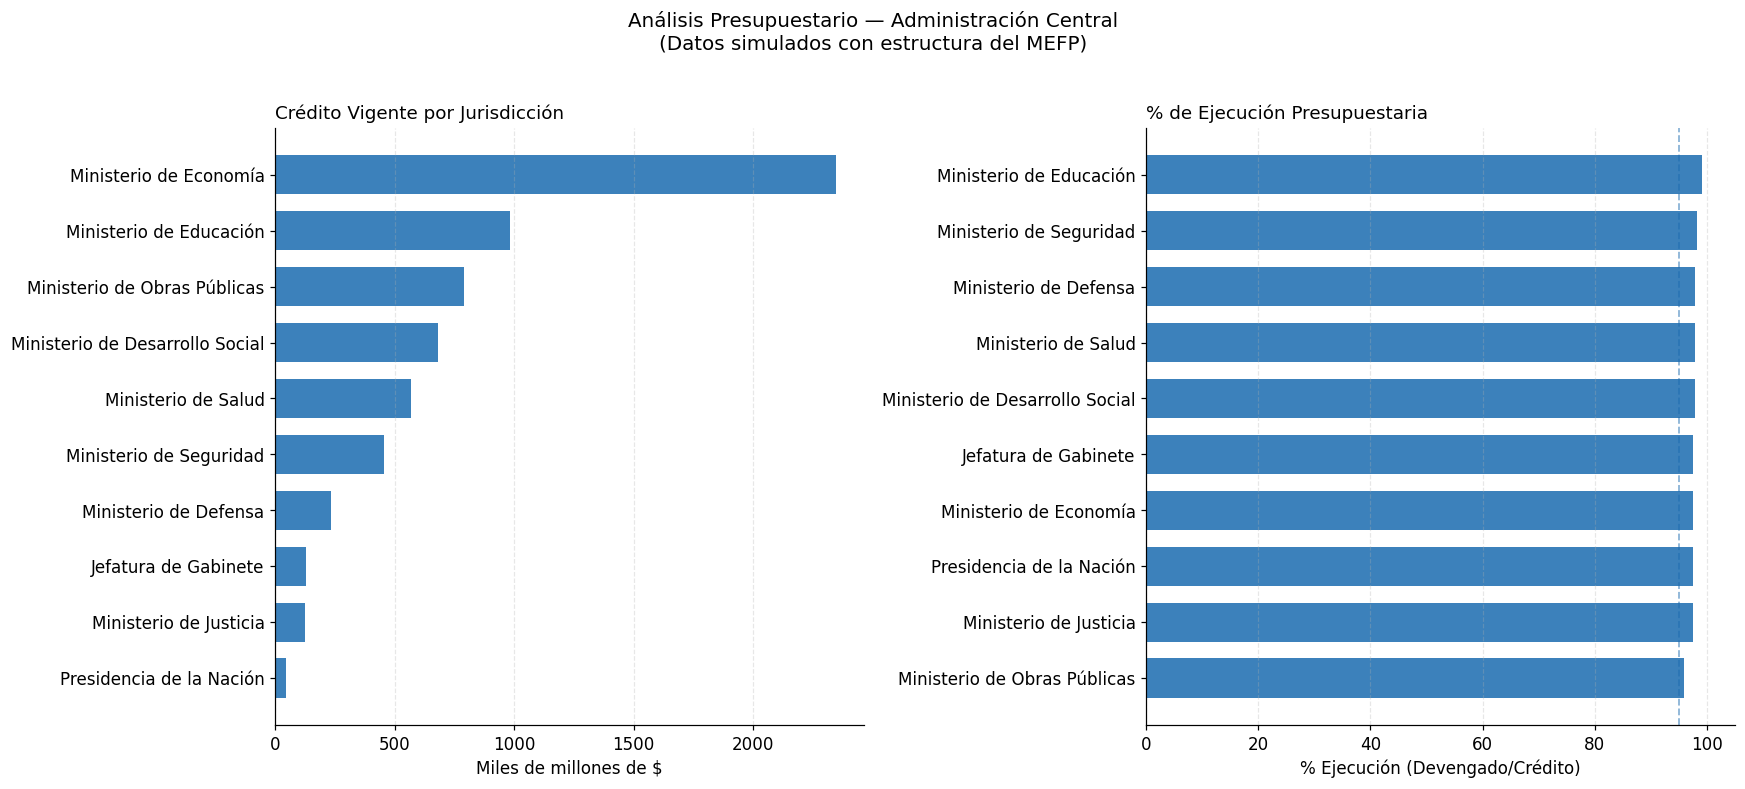


Nota: azul = ejecución ≥ 95% | naranja = 90–95% | rojo = < 90%


In [17]:
# Demostración del flujo completo (con datos sintéticos que simulan
# lo que obtendríamos de un PDF de presupuesto del MEFP)

print("=== Simulación: datos extraídos de un PDF de presupuesto ===")
print()

# Estos datos simulan la Tabla 5 del Proyecto de Ley de Presupuesto
# (Crédito por Jurisdicción - Administración Central)
datos_presupuesto_simulado = {
    "Jurisdicción": [
        "Presidencia de la Nación",
        "Jefatura de Gabinete",
        "Ministerio de Economía",
        "Ministerio de Salud",
        "Ministerio de Educación",
        "Ministerio de Defensa",
        "Ministerio de Seguridad",
        "Ministerio de Justicia",
        "Ministerio de Obras Públicas",
        "Ministerio de Desarrollo Social"
    ],
    "Crédito_Vigente_MM": [45230, 128450, 2345670, 567890, 980234,
                            234560, 456780, 123450, 789012, 678901],
    "Devengado_MM":       [44120, 125340, 2290450, 556780, 971230,
                            229870, 448920, 120340, 756780, 665430],
    "Pagado_MM":          [43890, 124560, 2280340, 548920, 965670,
                            226780, 445670, 119230, 745670, 659870]
}

df_presupuesto = pd.DataFrame(datos_presupuesto_simulado)

# Calcular % de ejecución
df_presupuesto["Ejecucion_pct"] = (
    df_presupuesto["Devengado_MM"] / df_presupuesto["Crédito_Vigente_MM"] * 100
).round(1)

df_presupuesto = df_presupuesto.sort_values("Crédito_Vigente_MM", ascending=False)

print("Tabla de presupuesto procesada:")
display(df_presupuesto)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: crédito vigente
ax1 = axes[0]
df_plot = df_presupuesto.sort_values("Crédito_Vigente_MM")
ax1.barh(df_plot["Jurisdicción"], df_plot["Crédito_Vigente_MM"] / 1000,
         color="#1a6baf", alpha=0.85, height=0.7)
ax1.set_xlabel("Miles de millones de $", fontsize=11)
ax1.set_title("Crédito Vigente por Jurisdicción", fontsize=12, loc='left')
ax1.grid(axis="x", alpha=0.3, linestyle="--")

# Panel derecho: % de ejecución
ax2 = axes[1]
df_plot2 = df_presupuesto.sort_values("Ejecucion_pct")
colores_ejec = ["#1a6baf" if v >= 95 else "#e8a020" if v >= 90 else "#e84040"
                for v in df_plot2["Ejecucion_pct"]]
ax2.barh(df_plot2["Jurisdicción"], df_plot2["Ejecucion_pct"],
         color=colores_ejec, alpha=0.85, height=0.7)
ax2.axvline(x=95, color="#1a6baf", linestyle="--", alpha=0.5, linewidth=1.2)
ax2.set_xlabel("% Ejecución (Devengado/Crédito)", fontsize=11)
ax2.set_title("% de Ejecución Presupuestaria", fontsize=12, loc='left')
ax2.set_xlim(0, 105)
ax2.grid(axis="x", alpha=0.3, linestyle="--")

plt.suptitle("Análisis Presupuestario — Administración Central\n"
             "(Datos simulados con estructura del MEFP)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nNota: azul = ejecución ≥ 95% | naranja = 90–95% | rojo = < 90%")


## 3.4 Consideraciones técnicas para PDFs reales

Al trabajar con PDFs del sector público argentino, tener en cuenta:

**PDFs nativos (texto seleccionable):**
- `pdfplumber` funciona directamente
- La extracción de tablas es automática pero puede requerir ajustes de `table_settings`

**PDFs escaneados (imágenes):**
- Requieren OCR (Optical Character Recognition)
- Biblioteca recomendada: `pytesseract` + `pdf2image`
- Instalación: `pip install pytesseract pdf2image` + instalar Tesseract OCR

**Ejemplo con OCR:**
```python
import pytesseract
from pdf2image import convert_from_path

# Convertir PDF a imágenes
images = convert_from_path("resolución_escaneada.pdf", dpi=300)

# Aplicar OCR a cada imagen
texto_completo = []
for i, img in enumerate(images):
    texto = pytesseract.image_to_string(img, lang="spa")
    texto_completo.append(texto)
    print(f"Página {i+1}: {len(texto)} caracteres extraídos")
```

**Parámetros avanzados de extracción de tablas en pdfplumber:**
```python
table_settings = {
    "vertical_strategy": "lines",    # o 'text', 'explicit'
    "horizontal_strategy": "lines",
    "snap_tolerance": 3,             # Tolerancia para alinear líneas
    "join_tolerance": 3,
    "edge_min_length": 3
}
tables = page.extract_tables(table_settings=table_settings)
```

---

## Resumen: ¿Qué técnica usar según la fuente?

| Fuente de datos | Técnica recomendada | Biblioteca |
|-----------------|---------------------|------------|
| API REST con JSON | `requests` | `requests`, `pandas` |
| CSV/Excel en URL pública | `pd.read_csv(url)` | `pandas` |
| Tabla HTML en web | Scraping con parser HTML | `requests`, `BeautifulSoup` |
| PDF nativo (texto seleccionable) | Extracción directa | `pdfplumber` |
| PDF escaneado (imagen) | OCR | `pytesseract`, `pdf2image` |

> **Principio general:** siempre preferir la fuente más estructurada disponible. Si hay una API, usarla. Si hay un CSV, descargarlo directamente. El scraping de HTML y el procesamiento de PDFs son el último recurso.

---

## Ejercicios

### Ejercicio 1 — Ampliar el scraping a otras tablas de Wikipedia

La página de Wikipedia sobre [Provincias de Argentina](https://es.wikipedia.org/wiki/Provincias_de_Argentina) contiene una tabla con información de todas las provincias (superficie, población, capital, etc.).

a) Scrapea esa tabla usando el mismo enfoque de la Parte 1  
b) Convertí las columnas de superficie y población a numéricas  
c) Calculá la **densidad poblacional** (habitantes/km²) para cada provincia  
d) Graficá un scatter de superficie vs. densidad poblacional, con etiquetas para las 5 provincias más densas

**Pista:** La URL es `https://es.wikipedia.org/wiki/Provincias_de_Argentina`

In [18]:
# Tu código aquí


### Ejercicio 2 — Análisis del IPC por categorías

Con los datos del IPC de datos.gob.ar ya descargados:

a) Calculá la **variación interanual** (YoY) para todas las categorías disponibles  
b) Identificá los **3 meses con mayor inflación** en el período y las categorías que más contribuyeron  
c) Graficá la variación interanual del nivel general y de alimentos (si está disponible) en el mismo gráfico  
d) ¿En qué períodos la inflación de alimentos superó al nivel general? ¿Qué implicancias de bienestar tiene esto?

**Pista:** La variación interanual es `(valor_mes_t / valor_mes_t-12 - 1) * 100`. Usá `.pct_change(12) * 100`.

In [19]:
# Tu código aquí


### Ejercicio 3 — Automatización del pipeline de datos

Construí una función `obtener_datos_provincia(provincia: str) -> dict` que:

a) Use los datos de la Parte 1 (PBG provincial de Wikipedia) para buscar la provincia  
b) Use la API del Banco Mundial (de la Clase 3) para obtener el PIB per cápita nacional de Argentina para el mismo año  
c) Retorne un diccionario con:
   - `nombre`: nombre de la provincia
   - `pbg_valor`: valor del PBG provincial (si está disponible)
   - `pbg_pct_pib`: porcentaje del PBI nacional (si está disponible)
   - `fuente_scraping`: URL usada para el scraping
   - `fuente_api`: URL de la API del Banco Mundial usada

d) Probá la función con al menos 3 provincias  
e) Reflexioná: ¿Qué desafíos encontraste para combinar datos de distintas fuentes?

**Pista:** Prestá atención a la consistencia de los nombres ("Buenos Aires" vs. "Province of Buenos Aires") cuando combinás fuentes.

In [20]:
# Tu código aquí
